**Documentação do Notebook: Churn_Model.ipynb**

Este notebook é nossa primeira versão do modelo de Churn após a clusterização.

Como não possuímos a variável exata de Churn, definimos nossa própria regra de "risco", por assim dizer. Tal regra é: se o cliente possui mais contratos cancelados do que ativos E um valor maior de contratos cancelados do que ativos, definimos isso como Churn.

Ao final do notebook se encontra uma análise prévia de CLV, onde, pode-se dizer que estamos "mockando" esta variável, por termos assumido uma regra.

Portanto, consideramos que para os clientes "Churnados", a variável SOMA_VL_CONTRATOS representa o valor total perdido pelo ocasional Churn, predito ou não.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.2f}'.format

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = pd.read_parquet('/content/drive/MyDrive/Compartilhar/MODELO_3_TREINO_TESTE/df_para_analise.parquet')

In [ ]:
df.head()

,CD_CLIENTE,QTD_PRODUTOS_DISTINTOS,QTD_TOTAL_PRODUTOS,SOMA_VL_CONTRATOS,LISTA_PRODUTOS,CONTRATOS_ATIVO,CONTRATOS_CANCELADO,CONTRATOS_FATURAR,CONTRATOS_GRATUITO,CONTRATOS_PENDENTE,CONTRATOS_SUSPENSO,CONTRATOS_TROCADO,VALOR_CONTRATOS_ATIVO,VALOR_CONTRATOS_CANCELADO,VALOR_CONTRATOS_FATURAR,VALOR_CONTRATOS_GRATUITO,VALOR_CONTRATOS_PENDENTE,VALOR_CONTRATOS_SUSPENSO,VALOR_CONTRATOS_TROCADO,PERIODICIDADE_00 - Mensal,PERIODICIDADE_01 - Bimestral,PERIODICIDADE_02 - Trimestral,PERIODICIDADE_03 - Quadrimestral,PERIODICIDADE_05 - Semestral,PERIODICIDADE_11 - Anual,DS_SEGMENTO,DS_SUBSEGMENTO,FAT_FAIXA,UF,EVENTDURATION_S,LICENCA_Conectado,LICENCA_Desconectado,LICENCA_Negado,QTD_PROPOSTAS_DISTINTAS,QTD_ITEMS_DISTINTOS_PROPOSTA,QTD_UNIDADES_TOTAIS,MEDIAN_MESES_BONIF,MEDIAN_VL_PCT_DESCONTO,MEDIAN_VL_PCT_DESC_TEMP,MEDIAN_PRC_UNITARIO_POR_PROPOSTA,MEDIAN_VALOR_TOTAL_PROPOSTA,MEDIAN_UNIDADES_POR_PROPOSTA,RELACIONAL_MEDIA_RESPOSTA_NPS,RELACIONAL_MEDIA_RESPOSTA_UNIDADE,RELACIONAL_MEDIA_NOTA_SUPTEC_AGI,RELACIONAL_MEDIA_NOTA_SUPTEC_ATEN,RELACIONAL_MEDIA_NOTA_COMERCIAL,RELACIONAL_MEDIA_NOTA_CUSTOS,RELACIONAL_MEDIA_NOTA_ADMFIN_ATEN,RELACIONAL_MEDIA_NOTA_SOFTWARE,RELACIONAL_MEDIA_NOTA_SOFTWARE_ATT,AQUISICAO_MEDIA_NOTA_NPS,AQUISICAO_MEDIA_NOTA_AGILIDADE,AQUISICAO_MEDIA_NOTA_CONHECIMENTO,AQUISICAO_MEDIA_NOTA_CUSTO,AQUISICAO_MEDIA_NOTA_FACILIDADE,AQUISICAO_MEDIA_NOTA_FLEXIBILIDADE,IMPLANTACAO_MEDIA_NOTA_NPS,IMPLANTACAO_MEDIA_NOTA_METODOLOGIA,IMPLANTACAO_MEDIA_NOTA_GESTAO,IMPLANTACAO_MEDIA_NOTA_CONHECIMENTO,IMPLANTACAO_MEDIA_NOTA_QUALIDADE,IMPLANTACAO_MEDIA_NOTA_COMUNICACAO,IMPLANTACAO_MEDIA_NOTA_PRAZOS,ONBOARDING_MEDIA_NOTA_RECOMENDACAO,ONBOARDING_MEDIA_NOTA_AJUDA,ONBOARDING_MEDIA_NOTA_TEMPO,ONBOARDING_MEDIA_NOTA_CLAREZA_CANAL,ONBOARDING_MEDIA_NOTA_CLAREZA_GERAL,ONBOARDING_MEDIA_NOTA_EXPECTATIVA,LINHA_PRODUTO_Consinco_QTD,LINHA_PRODUTO_Datasul_QTD,LINHA_PRODUTO_Protheus_QTD,LINHA_PRODUTO_RM_QTD,LINHA_PRODUTO_SARA_QTD,LINHA_PRODUTO_TOTVS Agro Bioenergia_QTD,LINHA_PRODUTO_TOTVS Agro Multicultivo_QTD,LINHA_PRODUTO_TOTVS Moda_QTD,LINHA_PRODUTO_Consinco_MEDIA_NOTA,LINHA_PRODUTO_Datasul_MEDIA_NOTA,LINHA_PRODUTO_Protheus_MEDIA_NOTA,LINHA_PRODUTO_RM_MEDIA_NOTA,LINHA_PRODUTO_SARA_MEDIA_NOTA,LINHA_PRODUTO_TOTVS Agro Bioenergia_MEDIA_NOTA,LINHA_PRODUTO_TOTVS Agro Multicultivo_MEDIA_NOTA,LINHA_PRODUTO_TOTVS Moda_MEDIA_NOTA,SUPORTE_MEDIA_NOTA_NPS,SUPORTE_MEDIA_NOTA_CONHECIMENTO_AG,SUPORTE_MEDIA_NOTA_SOLUCAO,SUPORTE_MEDIA_NOTA_TEMPO_RETORNO,SUPORTE_MEDIA_NOTA_FACILIDADE,SUPORTE_MEDIA_NOTA_SATISFACAO,QTD_TICKET_PARA_SUPORTE,GRUPO_NPS_detrator,GRUPO_NPS_passivo,GRUPO_NPS_promotor,QTD_TICKETS,PRIMEIRA_CRIACAO,ULTIMA_ATUALIZACAO,DIAS_DESDE_ULTIMA_ATUALIZACAO_MEAN,DIAS_DESDE_ULTIMA_ATUALIZACAO_MIN,DIAS_DESDE_ULTIMA_ATUALIZACAO_MAX,QTD_TIPO_INCIDENT,QTD_TIPO_PROBLEM,QTD_TIPO_QUESTION,QTD_TIPO_TASK,QTD_STATUS_CLOSED,QTD_STATUS_DELETED,QTD_STATUS_HOLD,QTD_STATUS_NEW,QTD_STATUS_OPEN,QTD_STATUS_PENDING,QTD_STATUS_SOLVED,QTD_PRIORIDADE_HIGH,QTD_PRIORIDADE_LOW,QTD_PRIORIDADE_NORMAL,QTD_PRIORIDADE_URGENT,MRR_12M,QTD_CONTRATACOES_12M,VLR_CONTRATACOES_12M,CLIENTE_DESDE,IDADE_DIAS,IDADE_ANOS,MACRO_SEGMENTO,rotulos_30_train,probabilidade_30_train,score_outlier_30_train,rotulos_preditos_30_test,rotulos_40_train,probabilidade_40_train,score_outlier_40_train,rotulos_preditos_40_test,conjunto,rotulos30,rotulos40
0,T00018,8,10,205.12,"[FEE - GDS INTERNACIONAL, ASSINATURA MENSAL IN...",1,4,0,5,0,0,0,203.06,2.00,0.00,0.06,0.00,0.00,0.00,10,0,0,0,0,0,SERVICOS,VIAGENS,"Faixa 02 - De 7,5 M ate 15 M",SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2025-02-07,2025-03-10,15.50,0.00,31.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,NaN,NaN,NaN,2002-01-01,8513,23.31,Pagante,None,NaN,NaN,P_C10,None,NaN,NaN,P_C5,Teste,P_C10,P_C5
1,T00053,60,80,96711

In [ ]:
condicao_qtd = df['CONTRATOS_CANCELADO'] > df['CONTRATOS_ATIVO']
condicao_valor = df['VALOR_CONTRATOS_CANCELADO'] > df['VALOR_CONTRATOS_ATIVO']
df['CHURN'] = (condicao_qtd & condicao_valor).astype(int)

In [ ]:
df['CHURN'].value_counts()

,count
CHURN,
0,9674
1,936


Iniciando a otimização de hiperparâmetros...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Melhores parâmetros encontrados:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

Acurácia do modelo otimizado: 0.9526

Relatório de Classificação (Modelo Otimizado):
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2902
           1       0.70      0.82      0.75       281

    accuracy                           0.95      3183
   macro avg       0.84      0.89      0.86      3183
weighted avg       0.96      0.95      0.95      3183



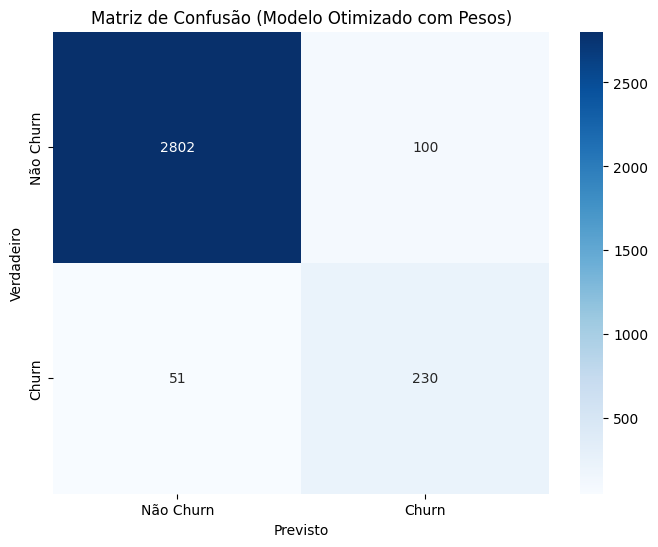


Dataset completo preparado para previsão.
Previsões unidas ao dataset original.

--- Clientes com Maior Probabilidade de Churn ---


,CONTRATOS_ATIVO,VALOR_CONTRATOS_ATIVO,CONTRATOS_CANCELADO,VALOR_CONTRATOS_CANCELADO,CHURN,Previsao_Churn,Probabilidade_Churn
CD_CLIENTE,,,,,,,
T16259,0,0.00,41,157269.15,1,1,1.00
T03000,0,0.00,288,176109.51,1,1,1.00
T16658,2,79.87,18,144430.12,1,1,1.00
T01695,2,114.98,73,111664.28,1,1,1.00
TA8688,2,315.74,36,101346.19,1,1,1.00
T54319,1,0.42,30,106572.81,1,1,1.00
T04281,4,264.07,36,160110.95,1,1,1.00
T08298,7,1617.08,76,155161.27,1,1,1.00
TA3205,1,117.51,36,58910.42,1,1,1.00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'CD_CLIENTE',
    'QTD_PRODUTOS_DISTINTOS', 'QTD_TOTAL_PRODUTOS', 'SOMA_VL_CONTRATOS',
    'CONTRATOS_ATIVO', 'VALOR_CONTRATOS_ATIVO', 'DS_SEGMENTO','FAT_FAIXA', 'UF', 'EVENTDURATION_S', 'IDADE_DIAS', 'MRR_12M', 'QTD_CONTRATACOES_12M', 'VLR_CONTRATACOES_12M',
    'rotulos30', 'rotulos40'
]
target = 'CHURN'
df_model = df[features + [target]].copy()
df_model.set_index('CD_CLIENTE', inplace=True)
X = df_model.drop(target, axis=1)
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

median_values = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)

X_train[cat_cols] = X_train[cat_cols].fillna('Desconhecido')
X_test[cat_cols] = X_test[cat_cols].fillna('Desconhecido')

X_train_processed = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_test_processed = X_test_processed.reindex(columns=X_train_processed.columns, fill_value=0)

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), weights))
sample_weights_train = np.array([class_weights_dict[label] for label in y_train])

print("Iniciando a otimização de hiperparâmetros...")

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

gbc_base_model = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gbc_base_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_processed, y_train, sample_weight=sample_weights_train)

best_gbc_model = grid_search.best_estimator_

print("\nMelhores parâmetros encontrados:")
print(grid_search.best_params_)

y_pred_best_gbc = best_gbc_model.predict(X_test_processed)

print(f"\nAcurácia do modelo otimizado: {accuracy_score(y_test, y_pred_best_gbc):.4f}")
print("\nRelatório de Classificação (Modelo Otimizado):")
print(classification_report(y_test, y_pred_best_gbc))

conf_matrix_best_gbc = confusion_matrix(y_test, y_pred_best_gbc)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_gbc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Churn', 'Churn'],
            yticklabels=['Não Churn', 'Churn'])
plt.title('Matriz de Confusão (Modelo Otimizado com Pesos)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
plt.close()

X_full_processed = X.copy()
X_full_processed[num_cols] = X_full_processed[num_cols].fillna(median_values)
X_full_processed[cat_cols] = X_full_processed[cat_cols].fillna('Desconhecido')

X_full_processed = pd.get_dummies(X_full_processed, columns=cat_cols, drop_first=True)

X_full_processed = X_full_processed.reindex(columns=X_train_processed.columns, fill_value=0)

print("\nDataset completo preparado para previsão.")

predicoes_todos = best_gbc_model.predict(X_full_processed)
probabilidades_todos = best_gbc_model.predict_proba(X_full_processed)[:, 1]

df_resultados = pd.DataFrame({
    'Previsao_Churn': predicoes_todos,
    'Probabilidade_Churn': probabilidades_todos
}, index=X_full_processed.index)

df_final = df.set_index('CD_CLIENTE').join(df_resultados)
print("Previsões unidas ao dataset original.")

print("\n--- Clientes com Maior Probabilidade de Churn ---")
colunas_para_ver = [
    'CONTRATOS_ATIVO',
    'VALOR_CONTRATOS_ATIVO',
    'CONTRATOS_CANCELADO',
    'VALOR_CONTRATOS_CANCELADO',
    'CHURN',
    'Previsao_Churn',
    'Probabilidade_Churn'
]
clientes_alto_risco = df_final.sort_values(by='Probabilidade_Churn', ascending=False)
clientes_alto_risco[colunas_para_ver].head(10)

In [ ]:
df_final.reset_index(inplace=True)

In [ ]:
df_final = df_final.drop(columns=['rotulos30', 'conjunto', 'rotulos_preditos_40_test', 'score_outlier_40_train', 'probabilidade_40_train',
                                  'rotulos_40_train', 'rotulos_preditos_30_test', 'score_outlier_30_train', 'probabilidade_30_train', 'rotulos_30_train'])

In [ ]:
df_final.head()

,CD_CLIENTE,QTD_PRODUTOS_DISTINTOS,QTD_TOTAL_PRODUTOS,SOMA_VL_CONTRATOS,LISTA_PRODUTOS,CONTRATOS_ATIVO,CONTRATOS_CANCELADO,CONTRATOS_FATURAR,CONTRATOS_GRATUITO,CONTRATOS_PENDENTE,CONTRATOS_SUSPENSO,CONTRATOS_TROCADO,VALOR_CONTRATOS_ATIVO,VALOR_CONTRATOS_CANCELADO,VALOR_CONTRATOS_FATURAR,VALOR_CONTRATOS_GRATUITO,VALOR_CONTRATOS_PENDENTE,VALOR_CONTRATOS_SUSPENSO,VALOR_CONTRATOS_TROCADO,PERIODICIDADE_00 - Mensal,PERIODICIDADE_01 - Bimestral,PERIODICIDADE_02 - Trimestral,PERIODICIDADE_03 - Quadrimestral,PERIODICIDADE_05 - Semestral,PERIODICIDADE_11 - Anual,DS_SEGMENTO,DS_SUBSEGMENTO,FAT_FAIXA,UF,EVENTDURATION_S,LICENCA_Conectado,LICENCA_Desconectado,LICENCA_Negado,QTD_PROPOSTAS_DISTINTAS,QTD_ITEMS_DISTINTOS_PROPOSTA,QTD_UNIDADES_TOTAIS,MEDIAN_MESES_BONIF,MEDIAN_VL_PCT_DESCONTO,MEDIAN_VL_PCT_DESC_TEMP,MEDIAN_PRC_UNITARIO_POR_PROPOSTA,MEDIAN_VALOR_TOTAL_PROPOSTA,MEDIAN_UNIDADES_POR_PROPOSTA,RELACIONAL_MEDIA_RESPOSTA_NPS,RELACIONAL_MEDIA_RESPOSTA_UNIDADE,RELACIONAL_MEDIA_NOTA_SUPTEC_AGI,RELACIONAL_MEDIA_NOTA_SUPTEC_ATEN,RELACIONAL_MEDIA_NOTA_COMERCIAL,RELACIONAL_MEDIA_NOTA_CUSTOS,RELACIONAL_MEDIA_NOTA_ADMFIN_ATEN,RELACIONAL_MEDIA_NOTA_SOFTWARE,RELACIONAL_MEDIA_NOTA_SOFTWARE_ATT,AQUISICAO_MEDIA_NOTA_NPS,AQUISICAO_MEDIA_NOTA_AGILIDADE,AQUISICAO_MEDIA_NOTA_CONHECIMENTO,AQUISICAO_MEDIA_NOTA_CUSTO,AQUISICAO_MEDIA_NOTA_FACILIDADE,AQUISICAO_MEDIA_NOTA_FLEXIBILIDADE,IMPLANTACAO_MEDIA_NOTA_NPS,IMPLANTACAO_MEDIA_NOTA_METODOLOGIA,IMPLANTACAO_MEDIA_NOTA_GESTAO,IMPLANTACAO_MEDIA_NOTA_CONHECIMENTO,IMPLANTACAO_MEDIA_NOTA_QUALIDADE,IMPLANTACAO_MEDIA_NOTA_COMUNICACAO,IMPLANTACAO_MEDIA_NOTA_PRAZOS,ONBOARDING_MEDIA_NOTA_RECOMENDACAO,ONBOARDING_MEDIA_NOTA_AJUDA,ONBOARDING_MEDIA_NOTA_TEMPO,ONBOARDING_MEDIA_NOTA_CLAREZA_CANAL,ONBOARDING_MEDIA_NOTA_CLAREZA_GERAL,ONBOARDING_MEDIA_NOTA_EXPECTATIVA,LINHA_PRODUTO_Consinco_QTD,LINHA_PRODUTO_Datasul_QTD,LINHA_PRODUTO_Protheus_QTD,LINHA_PRODUTO_RM_QTD,LINHA_PRODUTO_SARA_QTD,LINHA_PRODUTO_TOTVS Agro Bioenergia_QTD,LINHA_PRODUTO_TOTVS Agro Multicultivo_QTD,LINHA_PRODUTO_TOTVS Moda_QTD,LINHA_PRODUTO_Consinco_MEDIA_NOTA,LINHA_PRODUTO_Datasul_MEDIA_NOTA,LINHA_PRODUTO_Protheus_MEDIA_NOTA,LINHA_PRODUTO_RM_MEDIA_NOTA,LINHA_PRODUTO_SARA_MEDIA_NOTA,LINHA_PRODUTO_TOTVS Agro Bioenergia_MEDIA_NOTA,LINHA_PRODUTO_TOTVS Agro Multicultivo_MEDIA_NOTA,LINHA_PRODUTO_TOTVS Moda_MEDIA_NOTA,SUPORTE_MEDIA_NOTA_NPS,SUPORTE_MEDIA_NOTA_CONHECIMENTO_AG,SUPORTE_MEDIA_NOTA_SOLUCAO,SUPORTE_MEDIA_NOTA_TEMPO_RETORNO,SUPORTE_MEDIA_NOTA_FACILIDADE,SUPORTE_MEDIA_NOTA_SATISFACAO,QTD_TICKET_PARA_SUPORTE,GRUPO_NPS_detrator,GRUPO_NPS_passivo,GRUPO_NPS_promotor,QTD_TICKETS,PRIMEIRA_CRIACAO,ULTIMA_ATUALIZACAO,DIAS_DESDE_ULTIMA_ATUALIZACAO_MEAN,DIAS_DESDE_ULTIMA_ATUALIZACAO_MIN,DIAS_DESDE_ULTIMA_ATUALIZACAO_MAX,QTD_TIPO_INCIDENT,QTD_TIPO_PROBLEM,QTD_TIPO_QUESTION,QTD_TIPO_TASK,QTD_STATUS_CLOSED,QTD_STATUS_DELETED,QTD_STATUS_HOLD,QTD_STATUS_NEW,QTD_STATUS_OPEN,QTD_STATUS_PENDING,QTD_STATUS_SOLVED,QTD_PRIORIDADE_HIGH,QTD_PRIORIDADE_LOW,QTD_PRIORIDADE_NORMAL,QTD_PRIORIDADE_URGENT,MRR_12M,QTD_CONTRATACOES_12M,VLR_CONTRATACOES_12M,CLIENTE_DESDE,IDADE_DIAS,IDADE_ANOS,MACRO_SEGMENTO,rotulos40,CHURN,Previsao_Churn,Probabilidade_Churn
0,T00018,8,10,205.12,"[FEE - GDS INTERNACIONAL, ASSINATURA MENSAL IN...",1,4,0,5,0,0,0,203.06,2.00,0.00,0.06,0.00,0.00,0.00,10,0,0,0,0,0,SERVICOS,VIAGENS,"Faixa 02 - De 7,5 M ate 15 M",SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2025-02-07,2025-03-10,15.50,0.00,31.00,0.00,0.00,2.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,NaN,NaN,NaN,2002-01-01,8513,23.31,Pagante,P_C5,0,0,0.15
1,T00053,60,80,967114.98,"[SMS COLAB NEO 2500 DOC, HORA SUPORTE, PROGRE...",44,28,0,4,0,0,4,155716.89,805752.41,0.00,0.24,0.00,0.00,5645.44,80,0,0,0,0,0,MANUFATURA,BENS DURAVEIS,Faixa 05 - De 35 M ate 50 M,RJ,229.5

In [ ]:
df_final.shape

(10610, 128)

In [ ]:
df_final.to_parquet(r'/content/drive/MyDrive/Compartilhar/MODELO_3_TREINO_TESTE/df_churn_cliente.parquet', index=False)
df_final.to_csv(r'/content/drive/MyDrive/Compartilhar/MODELO_3_TREINO_TESTE/df_churn_cliente.csv', index=False)

In [ ]:
colunas_interesse = [
    'rotulos40',
    'QTD_PRODUTOS_DISTINTOS',
    'CONTRATOS_ATIVO',
    'CONTRATOS_CANCELADO',
    'CONTRATOS_GRATUITO',
    'VALOR_CONTRATOS_ATIVO',
    'VALOR_CONTRATOS_CANCELADO',
    'VALOR_CONTRATOS_GRATUITO',
    'MRR_12M',
    'QTD_CONTRATACOES_12M',
    'VLR_CONTRATACOES_12M',
    'DS_SEGMENTO',
    'FAT_FAIXA',
    'EVENTDURATION_S',
    'IDADE_DIAS',
    'QTD_TICKETS',
    'Probabilidade_Churn'
]

colunas_nota = [col for col in df_final.columns if 'NOTA_' in col]
colunas_interesse.extend(colunas_nota)

colunas_tipo_status = [col for col in df_final.columns if 'QTD_TIPO_' in col or 'QTD_STATUS_' in col]
colunas_interesse.extend(colunas_tipo_status)

df_para_analise_de_clusters = df_final[colunas_interesse]

analise_clusters = df_para_analise_de_clusters.groupby('rotulos40').agg({
    'QTD_PRODUTOS_DISTINTOS': 'mean',
    'CONTRATOS_ATIVO': 'mean',
    'CONTRATOS_CANCELADO': 'mean',
    'CONTRATOS_GRATUITO': 'mean',
    'VALOR_CONTRATOS_ATIVO': 'mean',
    'VALOR_CONTRATOS_CANCELADO': 'mean',
    'VALOR_CONTRATOS_GRATUITO': 'mean',
    'MRR_12M': 'mean',
    'QTD_CONTRATACOES_12M': 'mean',
    'VLR_CONTRATACOES_12M': 'mean',
    'DS_SEGMENTO': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'FAT_FAIXA': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'EVENTDURATION_S': 'mean',
    'IDADE_DIAS': 'mean',
    'QTD_TICKETS': 'mean',
    'Probabilidade_Churn': 'mean',
    **{col: 'mean' for col in colunas_nota},
    **{col: 'mean' for col in colunas_tipo_status}
}).reset_index()

In [ ]:
high_churn_threshold = 0.5

df_final['High_Churn_Risk'] = np.where(df_final['Probabilidade_Churn'] >= high_churn_threshold, 1, 0)

high_churn_customers_per_cluster = df_final.groupby('rotulos40').agg(
    Qtd_Clientes_Alto_Risco_Churn=('High_Churn_Risk', 'sum'),
    Qtd_Total_Clientes=('CD_CLIENTE', 'count')
).reset_index()

high_churn_customers_per_cluster['Percentual_Alto_Risco'] = (high_churn_customers_per_cluster['Qtd_Clientes_Alto_Risco_Churn'] / high_churn_customers_per_cluster['Qtd_Total_Clientes']) * 100
high_churn_customers_per_cluster = high_churn_customers_per_cluster.sort_values(by='Qtd_Clientes_Alto_Risco_Churn', ascending=False)

In [ ]:
etapas = {
    'Relacional': [col for col in df.columns if col.startswith('RELACIONAL_MEDIA_NOTA_')],
    'Aquisição': [col for col in df.columns if col.startswith('AQUISICAO_MEDIA_NOTA_')],
    'Implantação': [col for col in df.columns if col.startswith('IMPLANTACAO_MEDIA_NOTA_')],
    'Onboarding': [col for col in df.columns if col.startswith('ONBOARDING_MEDIA_NOTA_')],
    'Suporte': [col for col in df.columns if col.startswith('SUPORTE_MEDIA_NOTA_')],
    'Linha de Produto': [col for col in df.columns if 'LINHA_PRODUTO_' in col and '_MEDIA_NOTA' in col]
}

agg_funcs = {
    etapa: lambda x, cols=cols: x[cols].notna().any(axis=1).sum()
    for etapa, cols in etapas.items() if cols
}

contagem_por_cluster = df.groupby('rotulos40').apply(
    lambda x: pd.Series({
        etapa: x[cols].notna().any(axis=1).sum()
        for etapa, cols in etapas.items() if cols
    })
).astype(int)

contagem_por_cluster['Total_Clientes_Cluster'] = df['rotulos40'].value_counts()

/tmp/ipython-input-3406192755.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  contagem_por_cluster = df.groupby('rotulos40').apply(


In [ ]:
contagem_por_cluster.reset_index(inplace=True)

In [ ]:
df_merged = analise_clusters.merge(high_churn_customers_per_cluster, on='rotulos40', how='left')
df_merged = df_merged.merge(contagem_por_cluster, on='rotulos40', how='left')

In [ ]:
df_merged.to_parquet(r'/content/drive/MyDrive/Compartilhar/MODELO_3_TREINO_TESTE/df_churn_cluster.parquet', index=False)
df_merged.to_csv(r'/content/drive/MyDrive/Compartilhar/MODELO_3_TREINO_TESTE/df_churn_cluster.csv', index=False)

CLV

In [ ]:
import pandas as pd

In [ ]:
df_original = pd.read_parquet(r'/content/drive/MyDrive/Compartilhar/MODELO_3_TREINO_TESTE/df_churn_cliente.parquet')

In [ ]:
clusters_para_ignorar = ['P_Ruido', 'NP_Ruido']
df_final = df_original[~df_original['rotulos40'].isin(clusters_para_ignorar)].copy()

In [ ]:
COLUNA_CLUSTER = 'rotulos40'

In [ ]:
colunas_necessarias = [COLUNA_CLUSTER, 'CHURN', 'VALOR_CONTRATOS_ATIVO', 'SOMA_VL_CONTRATOS']

In [ ]:
# --- ANÁLISE 1: Qual o valor PERDIDO com os clientes que deram churn? ---
# SOMA_VL_CONTRATOS para ver o valor histórico total perdido.

print("\n\n--- Análise 1: Valor Histórico Total de Clientes Ativos vs. Churn ---")
analise_valor_perdido = df_final.groupby('CHURN')['SOMA_VL_CONTRATOS'].agg(['mean', 'sum', 'count']).rename(columns={
    'mean': 'Valor Histórico Médio por Cliente',
    'sum': 'Valor Histórico Total do Grupo',
    'count': 'Nº de Clientes'
}).sort_index(ascending=False)
analise_valor_perdido.index = analise_valor_perdido.index.map({1: 'Churn', 0: 'Ativo'})
display(analise_valor_perdido)

# --- ANÁLISE 2: Quais são nossos clusters ATIVOS mais valiosos? ---
# VALOR_CONTRATOS_ATIVO para ver a receita recorrente atual.

print("\n\n--- Análise 2: Valor da Receita Recorrente por Cluster (Apenas Clientes Ativos) ---")
df_ativos = df_final[df_final['CHURN'] == 0].copy()
analise_cluster_ativos = df_ativos.groupby(COLUNA_CLUSTER)['VALOR_CONTRATOS_ATIVO'].agg(['mean', 'sum', 'count']).rename(columns={
    'mean': 'Receita Recorrente Média por Cliente',
    'sum': 'Receita Recorrente Total do Cluster',
    'count': 'Nº de Clientes Ativos'
}).sort_values(by='Receita Recorrente Média por Cliente', ascending=False)
display(analise_cluster_ativos)

# --- ANÁLISE 3: Onde estamos perdendo mais valor? (A visão combinada) ---
# Valor histórico de SOMA_VL_CONTRATOS dos clientes que deram churn, agrupado por cluster.

print("\n\n--- Análise 3: Valor Histórico Perdido por Cluster (Apenas Clientes Churn) ---")
df_churned = df_final[df_final['CHURN'] == 1].copy()
if not df_churned.empty:
    analise_valor_perdido_cluster = df_churned.groupby(COLUNA_CLUSTER)['SOMA_VL_CONTRATOS'].agg(['mean', 'sum', 'count']).rename(columns={
        'mean': 'Valor Histórico Médio do Cliente Perdido',
        'sum': 'Valor Histórico Total Perdido no Cluster',
        'count': 'Nº de Clientes Perdidos'
    }).sort_values(by='Valor Histórico Total Perdido no Cluster', ascending=False)
    display(analise_valor_perdido_cluster)



--- Análise 1: Valor Histórico Total de Clientes Ativos vs. Churn ---


,Valor Histórico Médio por Cliente,Valor Histórico Total do Grupo,Nº de Clientes
CHURN,,,
Churn,31076.844732,1.622211e+07,522
Ativo,13666.674621,9.119772e+07,6673




--- Análise 2: Valor da Receita Recorrente por Cluster (Apenas Clientes Ativos) ---


,Receita Recorrente Média por Cliente,Receita Recorrente Total do Cluster,Nº de Clientes Ativos
rotulos40,,,
P_C0,42194.711705,2.911435e+06,69
P_C2,20044.172854,1.603534e+06,80
P_C3,16735.256966,8.534981e+05,51
P_C1,14356.473411,1.579212e+06,110
P_C5,11481.665091,7.165707e+07,6241
P_C4,5954.979738,3.811187e+05,64
NP_C0,0.000000,0.000000e+00,57
NP_C1,0.000000,0.000000e+00,1




--- Análise 3: Valor Histórico Perdido por Cluster (Apenas Clientes Churn) ---


,Valor Histórico Médio do Cliente Perdido,Valor Histórico Total Perdido no Cluster,Nº de Clientes Perdidos
rotulos40,,,
P_C5,32700.511832,1.507494e+07,461
P_C0,85748.764531,7.717389e+05,9
P_C2,27642.842470,1.105714e+05,4
P_C1,100534.130728,1.005341e+05,1
P_C3,20519.866482,8.207947e+04,4
P_C4,7185.767324,7.185767e+04,10
NP_C1,315.014396,1.039548e+04,33


/tmp/ipython-input-1791642692.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analise_valor_perdido.index, y='Valor Histórico Médio por Cliente', data=analise_valor_perdido, palette=['#d9534f', '#5cb85c'])


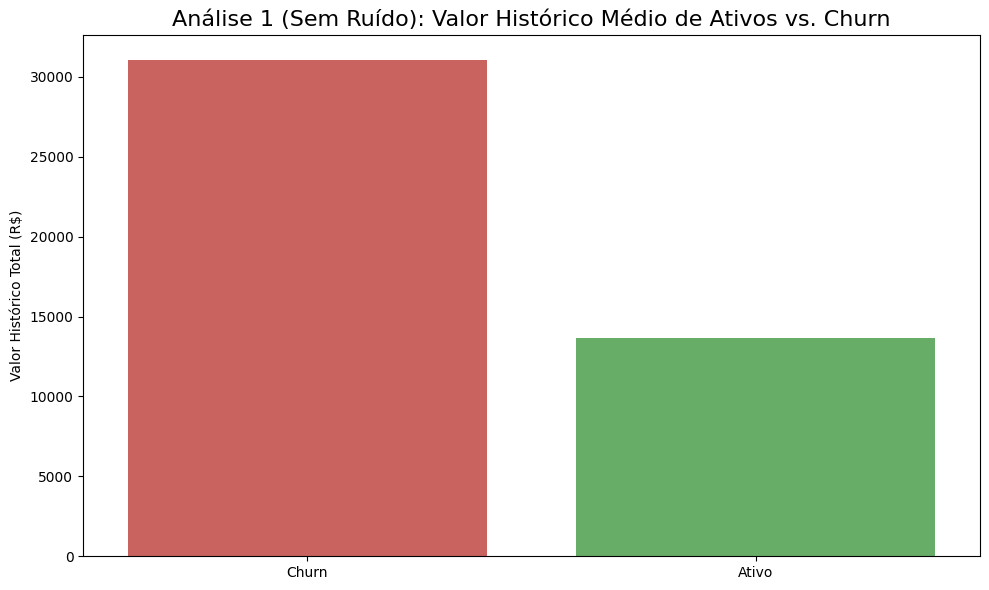

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=analise_valor_perdido.index, y='Valor Histórico Médio por Cliente', data=analise_valor_perdido, palette=['#d9534f', '#5cb85c'])
plt.title('Análise 1 (Sem Ruído): Valor Histórico Médio de Ativos vs. Churn', fontsize=16)
plt.ylabel('Valor Histórico Total (R$)')
plt.xlabel('')
plt.tight_layout()
plt.show()

/tmp/ipython-input-372890413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Receita Recorrente Total do Cluster', y=analise_cluster_ativos.index, data=analise_cluster_ativos, orient='h', palette='viridis')


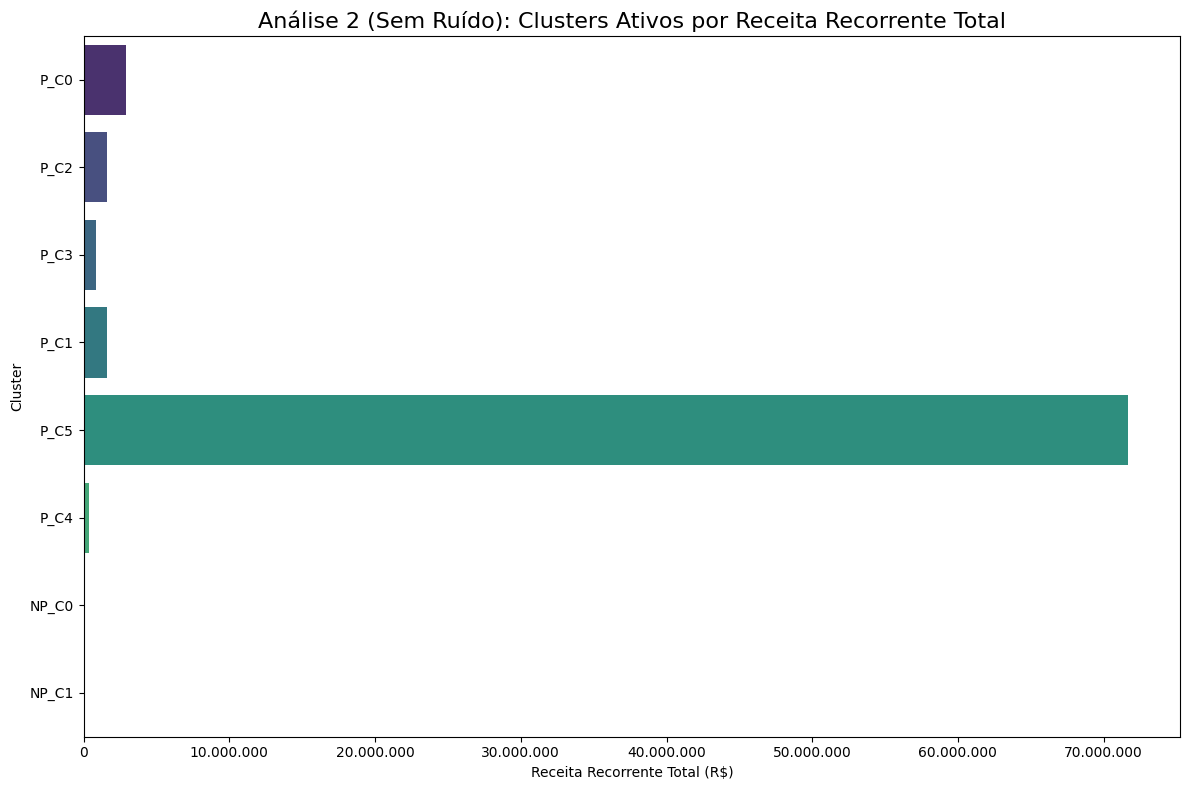

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Receita Recorrente Total do Cluster', y=analise_cluster_ativos.index, data=analise_cluster_ativos, orient='h', palette='viridis')
plt.title('Análise 2 (Sem Ruído): Clusters Ativos por Receita Recorrente Total', fontsize=16)
plt.xlabel('Receita Recorrente Total (R$)')
plt.ylabel('Cluster')

formatter = mticker.FuncFormatter(lambda x, _: '{:,.0f}'.format(x).replace(',', '.'))
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1845346386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Receita Recorrente Média por Cliente', y=analise_cluster_ativos.index, data=analise_cluster_ativos, orient='h', palette='viridis')


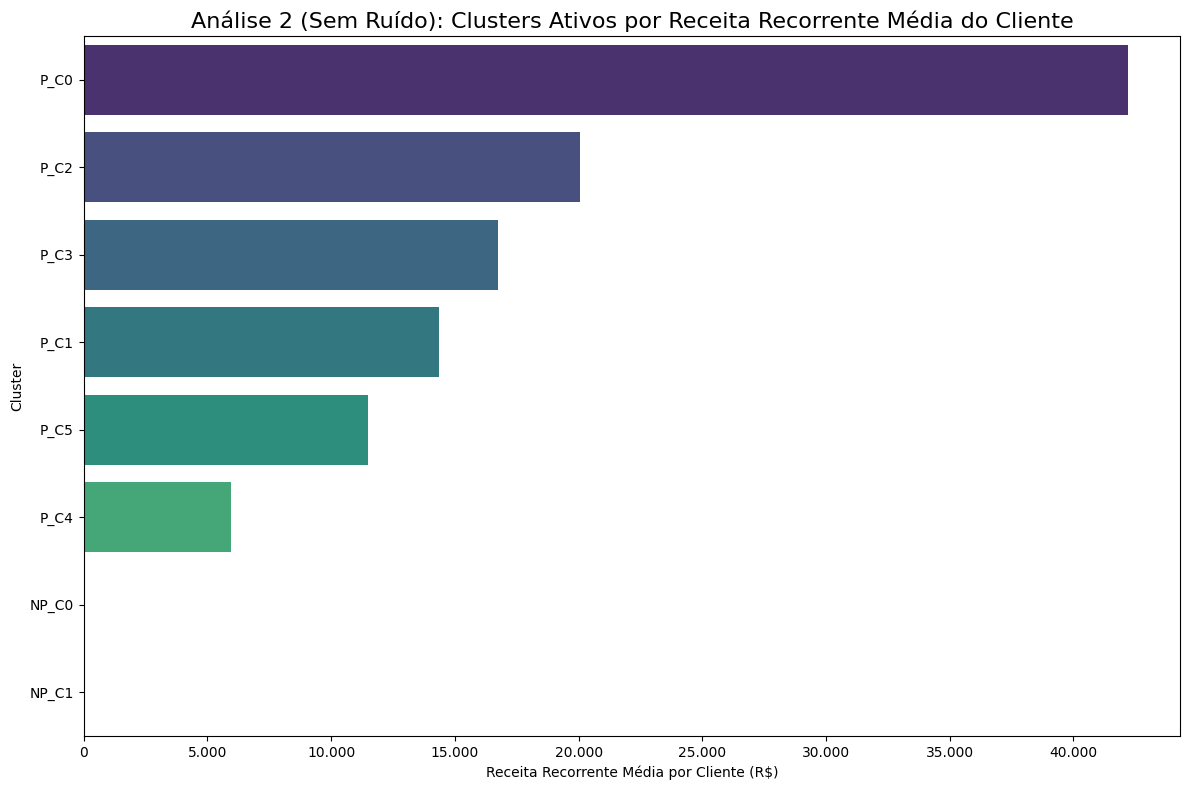

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Receita Recorrente Média por Cliente', y=analise_cluster_ativos.index, data=analise_cluster_ativos, orient='h', palette='viridis')
plt.title('Análise 2 (Sem Ruído): Clusters Ativos por Receita Recorrente Média do Cliente', fontsize=16)
plt.xlabel('Receita Recorrente Média por Cliente (R$)')
plt.ylabel('Cluster')

formatter = mticker.FuncFormatter(lambda x, _: '{:,.0f}'.format(x).replace(',', '.'))
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1159505462.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Valor Histórico Total Perdido no Cluster', y=analise_valor_perdido_cluster.index, data=analise_valor_perdido_cluster, orient='h', palette='plasma')


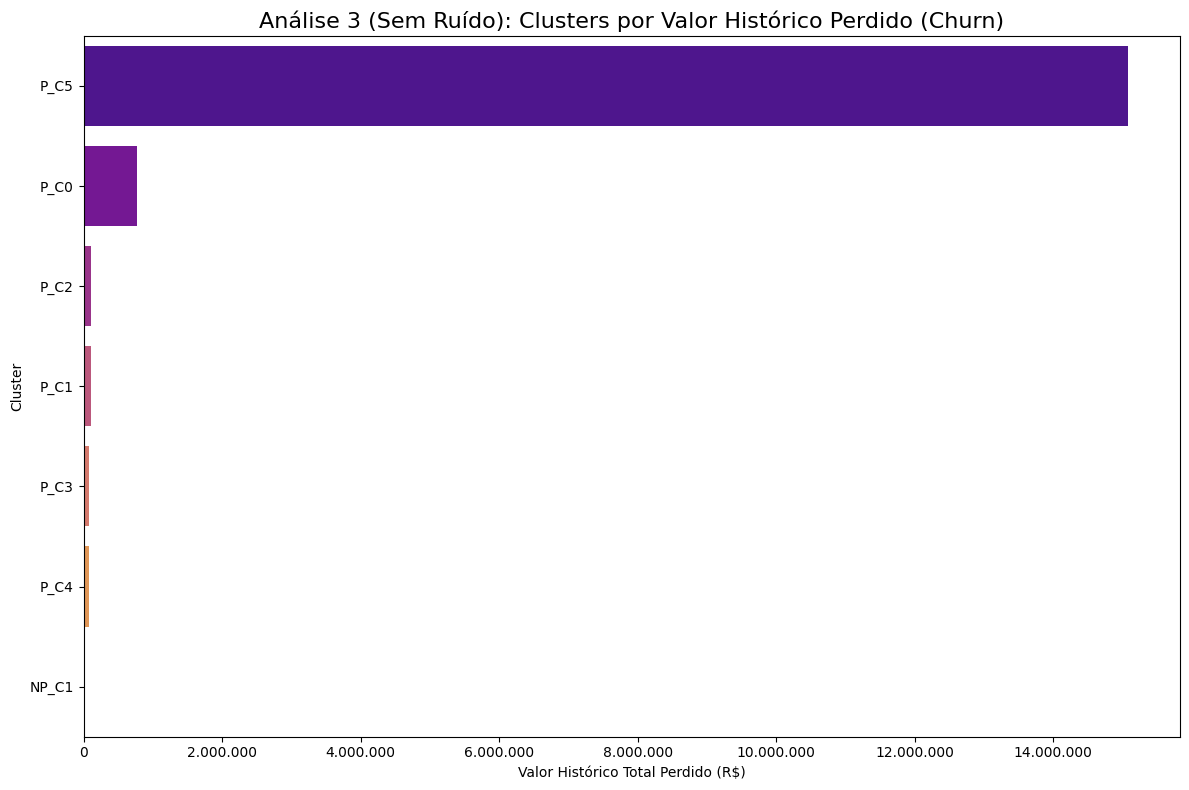

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Valor Histórico Total Perdido no Cluster', y=analise_valor_perdido_cluster.index, data=analise_valor_perdido_cluster, orient='h', palette='plasma')
plt.title('Análise 3 (Sem Ruído): Clusters por Valor Histórico Perdido (Churn)', fontsize=16)
plt.xlabel('Valor Histórico Total Perdido (R$)')
plt.ylabel('Cluster')

formatter = mticker.FuncFormatter(lambda x, _: '{:,.0f}'.format(x).replace(',', '.'))
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()